In [373]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import torch
from glob import glob

## Check data structure & Access the data and display an instance

In [105]:
DATA_PATH = r"/home/TisTis/Projects/Construction Safety Monitor/data/"

Number of training images: 2605 | (93.0%).

Number of validating images: 114 | (4.0%).

Number of testing images: 82 | (3.0%).

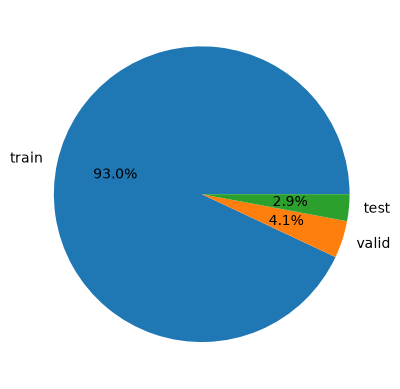

All tests passed!

Every image has its corespondent label in all train, valid and test sets.

In [268]:
train_images = sorted(glob(f"{DATA_PATH}train/images/*.jpg"))
train_labels = sorted(glob(f"{DATA_PATH}train/labels/*txt"))

valid_images = sorted(glob(f"{DATA_PATH}valid/images/*.jpg"))
valid_labels = sorted(glob(f"{DATA_PATH}valid/labels/*txt"))

test_images = sorted(glob(f"{DATA_PATH}test/images/*.jpg"))
test_labels = sorted(glob(f"{DATA_PATH}test/labels/*txt"))

train_count = len(train_images)
valid_count =  len(valid_images)
test_count = len(test_images)

total_count = test_count + train_count + valid_count

train_percentage = round(train_count/total_count,2)*100
valid_percentage = round(valid_count/total_count,2)*100
test_percentage = round(test_count/total_count,2)*100

print(f"Number of training images: {train_count} | ({train_percentage}%).")
print(f"Number of validating images: {valid_count} | ({valid_percentage}%).")
print(f"Number of testing images: {test_count} | ({test_percentage}%).")

plt.pie([train_count, valid_count, test_count], labels=["train","valid","test"], autopct='%1.1f%%')
plt.show()

assert len(train_images) == len(train_labels)
assert len(valid_images) == len(valid_labels)
assert len(test_images) == len(test_labels)
print("[green]All tests passed![/green]")
print("[bold]Every image has its corespondent label[/bold] in all train, valid and test sets.")

## Reading Yaml file

In [269]:
import yaml
from rich import print
from pprint import pprint

with open("../data/ppe_data.yaml", "r") as stream:
    try:
        data = yaml.safe_load(stream)
        print("--[bold green] YAML file was read successfully.[/bold green]--".center(100))
        pprint(data)
    except yaml.YAMLError as e:
        print(e)

-- YAML file was read successfully.--

{'names': ['Hardhat',
           'Mask',
           'NO-Hardhat',
           'NO-Mask',
           'NO-Safety Vest',
           'Person',
           'Safety Cone',
           'Safety Vest',
           'machinery',
           'vehicle'],
 'nc': 10,
 'test': '/kaggle/input/construction-site-safety-image-dataset-roboflow/test',
 'train': '/kaggle/input/construction-site-safety-image-dataset-roboflow/train',
 'val': '/kaggle/input/construction-site-safety-image-dataset-roboflow/valid'}


In [270]:
from tabulate import tabulate

classes_names = data["names"]
num_classes = data["nc"]

print(f"Number of Classes: {num_classes}")
print("Classes Names:")

seri_classes = pd.Series(classes_names)
print(seri_classes)

Number of Classes: 10

Classes Names:

0           Hardhat
1              Mask
2        NO-Hardhat
3           NO-Mask
4    NO-Safety Vest
5            Person
6       Safety Cone
7       Safety Vest
8         machinery
9           vehicle
dtype: str

In [271]:
filtered_classes = seri_classes.filter([0,2,4,5,7])
print(filtered_classes)

0           Hardhat
2        NO-Hardhat
4    NO-Safety Vest
5            Person
7       Safety Vest
dtype: str

### The only classes we care about are:
<ul>
<li>0 - HardHat</li>
<li>2 - NO-HardHat</li>
<li>4 - NO-Safety Vest</li>
<li>5 - Person</li>
<li>7 - Safety Vest</li>
</ul>

## Filtering the labels & checking for matching images with labels indices

In [272]:
import sys
import shutil

labels_classes = []

for label in train_labels: # for each label text file
    with open(label, "r") as f: # reads the file
        labels_classes.append(f.read().split("\n")) # append the list for this file after splitting it for "\n" since in the file each class is on a different line

In [273]:
labels_classes

[['0 0.0775416543763631 0.39375 0.09097043364502548 0.059375',
  '0 0.01640625 0.41328125 0.0328125 0.1203125',
  '3 0.04682291950167361 0.43671875 0.03935339149054773 0.05',
  '3 0.09124054001317838 0.45625 0.05019998789975162 0.034375',
  '5 0.16328125 0.4203125 0.3265625 0.178125',
  '5 0.17578125 0.43046875 0.2859375 0.1578125',
  '1 0.2578125 0.87109375 0.34375 0.2578125',
  '2 0.25390625 0.5953125 0.3515625 0.171875',
  '5 0.21484375 0.7546875 0.4296875 0.490625',
  '1 0.7734375 0.8890625 0.4375 0.221875',
  '2 0.78046875 0.6453125 0.4390625 0.175',
  '5 0.71484375 0.76953125 0.5703125 0.4609375'],
 ['5 0.1046875 0.38984375 0.209375 0.1578125',
  '5 0.1 0.40078125 0.2 0.1359375',
  '3 0.7658004593809523 0.00546875 0.007921588001272717 0.009375',
  '4 0.7573885227164068 0.02109375 0.034865896005727134 0.0421875',
  '4 0.8380572673854066 0.03828125 0.028852253341817756 0.0625',
  '5 0.840625 0.04921875 0.0625 0.0984375',
  '5 0.76640625 0.0546875 0.0703125 0.109375',
  '0 0.4195777

In [314]:
desired_classes = set(filtered_classes.index)
class_mapping = {
    0: 'Hardhat',
    2: 'NO-Hardhat',
    4: 'NO-Safety Vest',
    5: 'Person',
    7: 'Safety Vest'
}
class_counts = {name: 0 for name in class_mapping.values()}


# this will hold the cleaned and filtered data
filtered_labels_desired_classes = []

for full_label in labels_classes:
    current_image_labels = []
    
    for label in full_label:
        # Strip whitespace/newlines just in case
        clean_label = label.strip()
        
        # Skip empty strings to prevent index out of range error cause it happened when printing the labels 
        if not clean_label:
            continue
            
        # Split the string by spaces to separate the class ID from coordinates
        parts = clean_label.split()
        class_id = int(parts[0])

        # Check if the class ID is one of the ones we want
        if class_id in desired_classes:
            current_image_labels.append(clean_label)
            class_counts[class_mapping[class_id]] += 1
            
    # Add the filtered list back to our main list
    filtered_labels_desired_classes.append(current_image_labels)

In [ ]:
filtered_labels_desired_classes

In [280]:
assert train_images.index("/home/TisTis/Projects/Construction Safety Monitor/data/train/images/youtube-560_jpg.rf.2f8d44461cd667c44659a5751d05bd04.jpg") == train_labels.index("/home/TisTis/Projects/Construction Safety Monitor/data/train/labels/youtube-560_jpg.rf.2f8d44461cd667c44659a5751d05bd04.txt")

print("[bold green]Test ran successfully[/bold green], the image and its label has the same index.")

Test ran successfully, the image and its label has the same index.

In [300]:
# len(train_images), len(filtered_labels_desired_classes)
filtered_labels_desired_classes[190], train_images[190]
# filtered_labels_desired_classes[142:].index([])

(['5 0.4484375 0.16015625 0.521875 0.3203125',
  '0 0.98515625 0.128125 0.0296875 0.05',
  '7 0.96875 0.20703125 0.0625 0.1265625',
  '5 0.9796875 0.30234375 0.040625 0.3796875',
  '5 0.9203125 0.265625 0.159375 0.409375'],
 '/home/TisTis/Projects/Construction Safety Monitor/data/train/images/2008_008337_jpg.rf.5590da143ecce5f4a253645df18158c1.jpg')

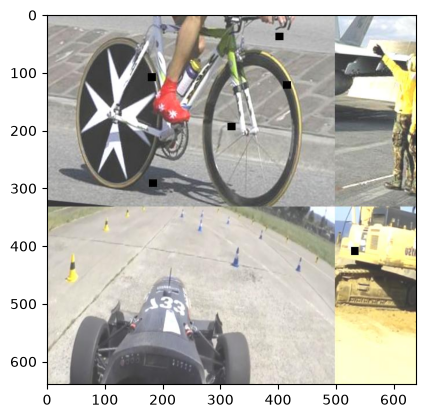

In [301]:
plt.imshow(plt.imread(train_images[190]))

## Classes Distribution

In [321]:
for class_name, class_count in class_counts.items():
    print(f"{class_name}:{class_count}")

Hardhat:3145

NO-Hardhat:2317

NO-Safety Vest:3962

Person:9532

Safety Vest:3033

### Plotting the distribution

In [323]:
classes = list(class_counts.keys())
counts = list(class_counts.values())

Dominant Class

Person is the dominant class with 43.0% of all the objects across all the of the training images.

---

Hardhat VS. NO-Hardhat

Hardhat is slightly larger than NO-Hardhat with 3.0% difference of all the objects across all the of the training 
images.

---

Safety Vest VS. NO-Safety Vest

NO-Safety Vest is slightly larger than Safety Vest with 4.0% difference of all the objects across all the of the 
training images.

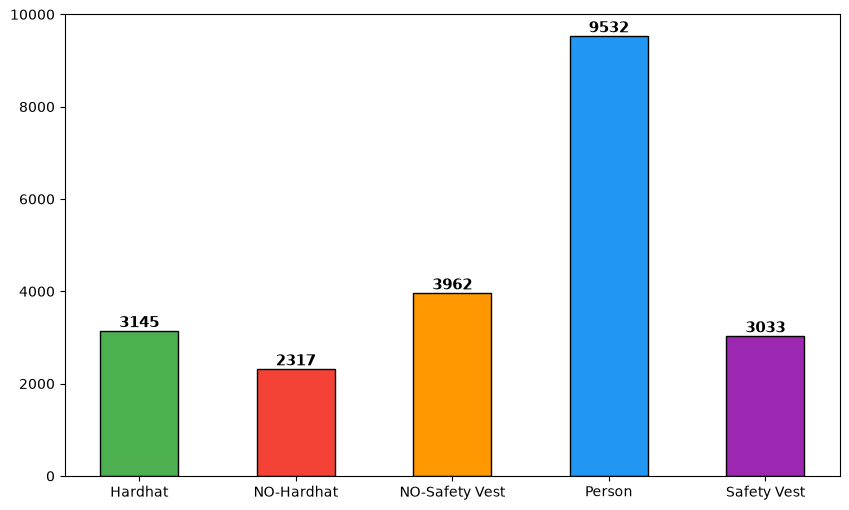

In [367]:
plt.figure(figsize=(10,6))
bars = plt.bar(classes, counts, color=['#4CAF50', '#F44336', '#FF9800', '#2196F3', '#9C27B0'], edgecolor='black', width=0.5)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', va='bottom', fontsize=11, fontweight='bold')


print(f"[bold purple]Dominant Class[/bold purple]".center(112))
print(f"[bold]Person[/bold] is the dominant class with {round(class_counts["Person"]/sum(class_counts.values()), 2) * 100}% of all the objects across all the of the training images.")
print("---")
print(f"[bold purple]Hardhat VS. NO-Hardhat[/bold purple]".center(112))
print(f"[bold]Hardhat[/bold] is slightly larger than [bold]NO-Hardhat[/bold] with {round(round(class_counts["Hardhat"]/sum(class_counts.values()), 2) * 100 - round(class_counts["NO-Hardhat"]/sum(class_counts.values()), 2) * 100, 1)}% difference of all the objects across all the of the training images.")
print("---")
print(f"[bold purple]Safety Vest VS. NO-Safety Vest[/bold purple]".center(112))
print(f"[bold]NO-Safety Vest[/bold] is slightly larger than [bold]Safety Vest[/bold] with {round(round(class_counts["NO-Safety Vest"]/sum(class_counts.values()), 2) * 100 - round(class_counts["Safety Vest"]/sum(class_counts.values()), 2) * 100, 1)}% difference of all the objects across all the of the training images.")

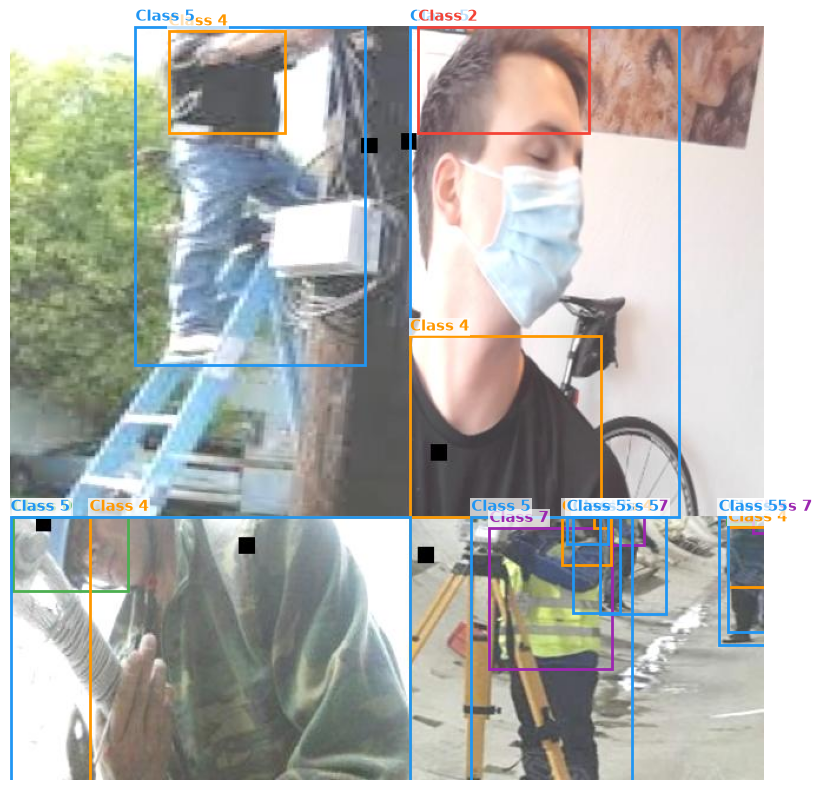

In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Map classes to specific colors for visual clarity
class_colors = {
    0: '#4CAF50',  # Hardhat (Green)
    2: '#F44336',  # NO-Hardhat (Red)
    4: '#FF9800',  # NO-Safety Vest (Orange)
    5: '#2196F3',  # Person (Blue)
    7: '#9C27B0'   # Safety Vest (Purple)
}

# Determine how many images to plot (up to 20) safely
num_samples = min(20, len(train_images))

# 1. Select 20 unique random indices from your dataset
random_indices = random.sample(range(len(train_images)), num_samples)

# 2. Setup a 5x4 grid layout with a large figure size so boxes remain visible
fig, axes = plt.subplots(5, 4, figsize=(24, 20))

# Flatten the 2D grid into a 1D list to easily iterate over it
axes_flat = axes.flatten()

# 3. Loop through the randomly selected indices and their designated subplot
for i, image_index in enumerate(random_indices):
    ax = axes_flat[i]
    
    try:
        # Load the specific image
        image = plt.imread(train_images[image_index])
        img_height, img_width = image.shape[:2]
        
        # Display image and set a title to track the index
        ax.imshow(image)
        ax.set_title(f"Image Index: {image_index}", fontsize=12, fontweight='bold')
        
        # 4. Loop through EVERY label string for this specific image
        for label_string in filtered_labels_desired_classes[image_index]:
            
            # Clean and split the string safely
            parts = label_string.strip().split()
            
            # Skip any empty or malformed lines that don't have exactly 5 values
            if len(parts) != 5:
                continue
                
            class_id = int(parts[0])
            x_center_norm = float(parts[1])
            y_center_norm = float(parts[2])
            width_norm = float(parts[3])
            height_norm = float(parts[4])

            # 5. Denormalize coordinates back to actual image pixels
            box_width = width_norm * img_width
            box_height = height_norm * img_height
            x_center = x_center_norm * img_width
            y_center = y_center_norm * img_height

            # 6. Convert the Center (x, y) to the Top-Left corner (xmin, ymin)
            xmin = x_center - (box_width / 2)
            ymin = y_center - (box_height / 2)

            # Get the assigned color for this class, default to red if not found
            color = class_colors.get(class_id, "red")

            # 7. Create a rectangle patch
            rect = patches.Rectangle(
                (xmin, ymin), 
                box_width, 
                box_height, 
                linewidth=2, 
                edgecolor=color, 
                facecolor="none"
            )

            # 8. Add the patch and text label to the axes
            ax.add_patch(rect)
            ax.text(
                xmin, 
                ymin - 5, 
                f"Class {class_id}", 
                color=color, 
                fontsize=9, 
                fontweight="bold",
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
            )
            
    except Exception as e:
        # If an image fails to load, mark it clearly on the grid without crashing the loop
        ax.text(0.5, 0.5, f"Error Loading\nIndex {image_index}", ha='center', va='center', color='red', fontsize=12)
         
    # Clean up the display by hiding the axis numbers for each subplot
    ax.axis('off')

# 9. Turn off any unused subplots (if your dataset happens to have fewer than 20 images)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

# Adjust layout to prevent overlapping and display the grid
plt.tight_layout()
plt.show()

In [ ]:
filtered_labels_desired_classes

'/home/TisTis/Projects/Construction Safety Monitor/data/train/labels/005180_jpg.rf.77e5bbc190a7bde710749bae284e6fff.txt'